## DQN example

I am trying to implement DQN example in Du(2020).

It seems that my implementation error is preventing the agent from being trained

notes 
* sigma adjust (yearly / daily / simulation step)
* huber loss 

todo
* batch size - ensemble sampling 


In [1]:
import torch
print(torch.cuda.is_available())
from rl import * 
import pandas as pd 
import numpy as np 

True


<Axes: title={'center': 'TTM = 10day, daily vol = 0.01'}, xlabel='underlying'>

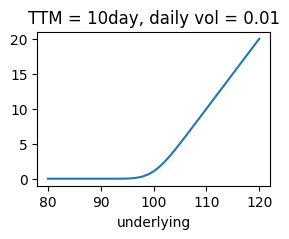

In [2]:
df = pd.DataFrame({
    "strike":[100] * 41, #[98, 99, 100, 101, 102]
    "underlying": np.arange(80,121).tolist()
    }) 
df["ttm"] = 10/360
df["r"] = 0
df["sigma"] = 0.01
# df["call_price"] = df
df["call_price"] = df.apply(lambda x: BlackScholesOracle.call_price(torch.tensor(x["underlying"]), torch.tensor(x["strike"]), x["ttm"], x["r"], x["sigma"]).item(), axis=1)
df.set_index("underlying")["call_price"].plot( figsize= (3,2), title= "TTM = 10day, daily vol = 0.01")

In [3]:
cfg = dict(
    S0=100.0, K=100.0, T=10.0/252.0, D =5, sigma=0.01, kappa=0.1, cost_multiplier=1.0, tick_size=0.1
)

# rl.Config.action_space = [-10.0, -5.0, 0.0, 5.0, 10.0] # Need to be modified, but I think this is not the main problem

env = OptionReplicationEnv(
    **cfg
)
agent = dqn(state_dim = 4, hidden_dim =64)
optimizer = optim.Adam(agent.parameters(), lr= 0.001)
loss_log = []

# for epoch in range(150):
for epoch in range(10):
    history = []
    print("epoch", epoch)

    # NUM_EPISODES = 3000
    NUM_EPISODES = 100

    # ==========================================
    # 1. Simulating the environment to gather Data
    # ==========================================
    for _ in range(NUM_EPISODES):
        state = env.reset()
        done = False
        while not done:
            action = agent.get_action(state, epsilon=0.1)
            next_state, reward, done = env.step(action)
            
            # IMPORTANT: Save 'next_state' and 'done' into history
            # we use float() for reward and done to ensure they are python floats, not tensors
            history.append((state, action, float(reward), next_state, float(done)))
            state = next_state
            
    # ==========================================
    # 2. Ensemble Sampling (Batch Training)
    # ==========================================
    # Sample 10% from the collected trajectories
    sample_size = int(len(history) * 0.1)

    if len(history) >= sample_size and sample_size > 0:
        # 1. Sample exactly `sample_size` transitions (breaks correlation)
        batch = random.sample(history, sample_size)
        
        # 2. Unpack the batch into separated lists using `zip(*batch)`
        states, actions, rewards, next_states, dones = zip(*batch)
        
        # 3. Stack lists into batched PyTorch Tensors
        states_t      = torch.stack(states)                            # Shape: [sample_size, 4]
        actions_t     = torch.tensor(actions, dtype=torch.long)        # Shape: [sample_size]
        rewards_t     = torch.tensor(rewards, dtype=torch.float32)     # Shape: [sample_size]
        next_states_t = torch.stack(next_states)                       # Shape: [sample_size, 4]
        dones_t       = torch.tensor(dones, dtype=torch.float32)       # Shape: [sample_size]
        
        # 4. Perform a SINGLE batched forward pass and loss calculation
        # FIXME batch size is too large. Is it a standard implemenation?
        loss = agent.td_loss(states_t, actions_t, rewards_t, next_states_t, dones_t)
        
        # 5. One backprop step for the entire batch
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        print(f"Collected total {len(history)} transitions.")
        print(f"Trained on {sample_size} samples (10%). Loss: {loss.item():.4f}")
        loss_log.append(loss.item())

epoch 0
Collected total 5100 transitions.
Trained on 510 samples (10%). Loss: 129426.8750
epoch 1
Collected total 5100 transitions.
Trained on 510 samples (10%). Loss: 79726.9844
epoch 2
Collected total 5100 transitions.
Trained on 510 samples (10%). Loss: 64088.1523
epoch 3
Collected total 5100 transitions.
Trained on 510 samples (10%). Loss: 72894.4844
epoch 4
Collected total 5100 transitions.
Trained on 510 samples (10%). Loss: 66293.3984
epoch 5
Collected total 5100 transitions.
Trained on 510 samples (10%). Loss: 51185.9883
epoch 6
Collected total 5100 transitions.
Trained on 510 samples (10%). Loss: 22969.7871
epoch 7
Collected total 5100 transitions.
Trained on 510 samples (10%). Loss: 20716.2520
epoch 8
Collected total 5100 transitions.
Trained on 510 samples (10%). Loss: 15096.9072
epoch 9
Collected total 5100 transitions.
Trained on 510 samples (10%). Loss: 12691.2080


<Axes: >

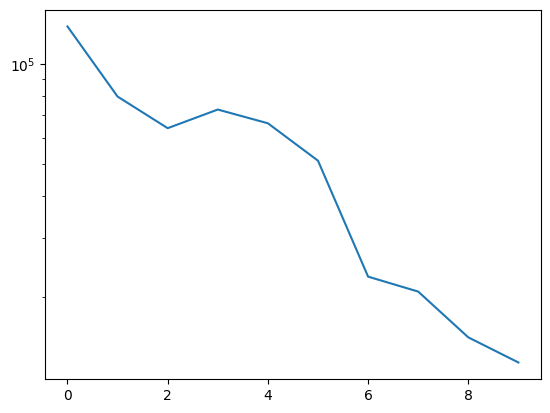

In [4]:
import matplotlib.pyplot as plt 
pd.Series(loss_log).plot(logy=True)

,underlying,position,action,reward,underlying_,u_ret,cum_ret
0,101.715454,-54.0,-54,-1.324489,171.545410,NaN,-1.324489
1,101.145615,-108.0,-54,-4.700969,114.561462,-0.569839,-6.025457
2,100.467232,-162.0,-54,-123.903477,46.723175,-0.678383,-129.928934
3,102.548126,-216.0,-54,-35.341379,254.812622,2.080894,-165.270313
4,101.576065,-270.0,-54,-82.152139,157.606506,-0.972061,-247.422452
5,102.696701,-324.0,-42,-26.751570,269.670105,1.120636,-274.174022
6,103.226822,-366.0,-42,-103.166260,322.682190,0.530121,-377.340282
7,104.190475,-408.0,-42,-292.572578,419.047546,0.963654,-669.912860
8,102.616585,-450.0,-41,-137.878652,261.658478,-1.573891,-807.791512
9,103.568558,-491.0,45,-228.170957,356.855774,0.951973,-1035.962469


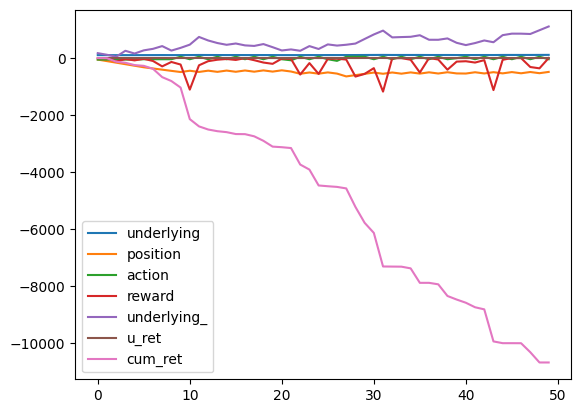

In [5]:
ss = []
ps = []
aa = []
rs = []
for state, action, reward, _, _ in history: # state, action, float(reward), next_state, float(done)
    underlying, _, pos, _ = state.tolist()
    ss.append(underlying)
    ps.append(pos)
    aa.append(action)
    rs.append(reward)

import matplotlib.pyplot as plt 
# n = 1 * 50
n = len(ss) - 50
df = pd.DataFrame({
    "underlying": ss[n:n+50],
    "position" : ps[n:n+50], 
    "action": aa[n:n+50], 
    "reward": rs[n:n+50] 
})
df["underlying_"] =  (df["underlying"] - 100) * 100
df["u_ret"] = df["underlying"].diff()
df["reward"] /= 100
df["cum_ret"] = df["reward"].cumsum() 
df["action"] -= 100
# df["underlying"].plot()
df.plot()
df

<Axes: title={'center': 'Daily price change distributionstd = 0.03'}, ylabel='Frequency'>

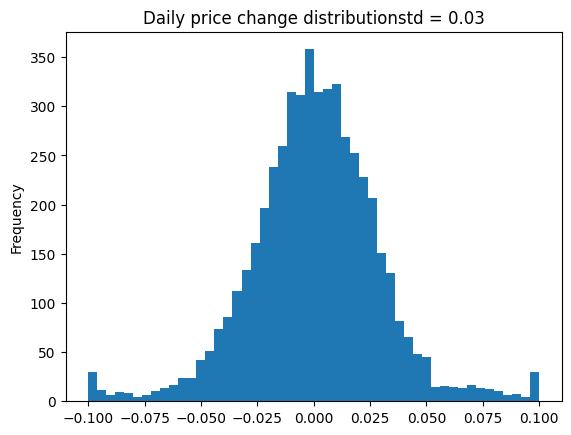

In [6]:
import pandas as pd 
df_ret = pd.Series(ss).pct_change(5)
df_ret.clip(-0.1,0.1).plot.hist(bins=50, title="Daily price change distribution" + f"std = {df_ret.std().round(3)}")

In [7]:
cfg = dict(
    S0=100.0, K=100.0, T=10.0/252.0, D =5, sigma=0.01, kappa=0.1, cost_multiplier=1.0, tick_size=0.1
)

# rl.Config.action_space = [-10.0, -5.0, 0.0, 5.0, 10.0] # Need to be modified, but I think this is not the main problem

env = OptionReplicationEnv(
    **cfg
)
agent = dqn(state_dim = 4, hidden_dim =64)
optimizer = optim.Adam(agent.parameters(), lr= 0.001)
loss_log = []

# for epoch in range(150):
for epoch in range(50):
    history = []
    print("epoch", epoch)

    # NUM_EPISODES = 3000
    NUM_EPISODES = 300

    # ==========================================
    # 1. Simulating the environment to gather Data
    # ==========================================
    for _ in range(NUM_EPISODES):
        state = env.reset()
        done = False
        while not done:
            action = agent.get_action(state, epsilon=0.1)
            next_state, reward, done = env.step(action)
            
            # IMPORTANT: Save 'next_state' and 'done' into history
            # we use float() for reward and done to ensure they are python floats, not tensors
            history.append((state, action, float(reward), next_state, float(done)))
            state = next_state
            
    # ==========================================
    # 2. Ensemble Sampling (Batch Training)
    # ==========================================
    # Sample 10% from the collected trajectories
    sample_size = int(len(history) * 0.1)

    if len(history) >= sample_size and sample_size > 0:
        # 1. Sample exactly `sample_size` transitions (breaks correlation)
        batch = random.sample(history, sample_size)
        
        # 2. Unpack the batch into separated lists using `zip(*batch)`
        states, actions, rewards, next_states, dones = zip(*batch)
        
        # 3. Stack lists into batched PyTorch Tensors
        states_t      = torch.stack(states)                            # Shape: [sample_size, 4]
        actions_t     = torch.tensor(actions, dtype=torch.long)        # Shape: [sample_size]
        rewards_t     = torch.tensor(rewards, dtype=torch.float32)     # Shape: [sample_size]
        next_states_t = torch.stack(next_states)                       # Shape: [sample_size, 4]
        dones_t       = torch.tensor(dones, dtype=torch.float32)       # Shape: [sample_size]
        
        # 4. Perform a SINGLE batched forward pass and loss calculation
        loss = agent.td_loss(states_t, actions_t, rewards_t, next_states_t, dones_t)
        
        # 5. One backprop step for the entire batch
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        print(f"Collected total {len(history)} transitions.")
        print(f"Trained on {sample_size} samples (10%). Loss: {loss.item():.4f}")
        loss_log.append(loss.item())

epoch 0
Collected total 15300 transitions.
Trained on 1530 samples (10%). Loss: 367243.0625
epoch 1
Collected total 15300 transitions.
Trained on 1530 samples (10%). Loss: 11306.2881
epoch 2
Collected total 15300 transitions.
Trained on 1530 samples (10%). Loss: 7617.1323
epoch 3
Collected total 15300 transitions.
Trained on 1530 samples (10%). Loss: 40507.9609
epoch 4
Collected total 15300 transitions.
Trained on 1530 samples (10%). Loss: 6502.3647
epoch 5
Collected total 15300 transitions.
Trained on 1530 samples (10%). Loss: 5086.6367
epoch 6
Collected total 15300 transitions.
Trained on 1530 samples (10%). Loss: 8567.6914
epoch 7
Collected total 15300 transitions.
Trained on 1530 samples (10%). Loss: 7251.7188
epoch 8
Collected total 15300 transitions.
Trained on 1530 samples (10%). Loss: 8999.5000
epoch 9
Collected total 15300 transitions.
Trained on 1530 samples (10%). Loss: 21054.3633
epoch 10
Collected total 15300 transitions.
Trained on 1530 samples (10%). Loss: 53099.7500
epo

<Axes: >

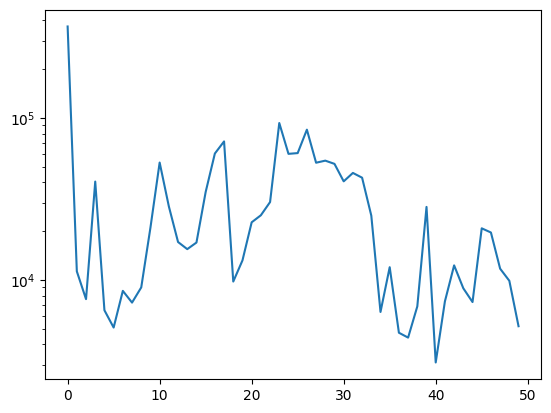

In [8]:
import matplotlib.pyplot as plt 
pd.Series(loss_log).plot(logy=True)

,underlying,position,action,reward,underlying_,u_ret,cum_ret
0,99.257904,-79.0,54,-12.049047,-74.209595,NaN,-12.049047
1,100.347618,-25.0,-45,0.047112,34.761810,1.089714,-12.001934
2,100.185303,-70.0,91,-15.571796,18.530273,-0.162315,-27.573730
3,98.361275,21.0,-79,-0.193335,-163.872528,-1.824028,-27.767065
4,98.240860,-58.0,91,-5.535482,-175.914001,-0.120415,-33.302547
5,99.111237,33.0,26,-0.270894,-88.876343,0.870377,-33.573441
6,100.164162,59.0,6,-0.082970,16.416168,1.052925,-33.656411
7,101.770279,65.0,6,-0.142816,177.027893,1.606117,-33.799227
8,102.570961,71.0,10,-0.099738,257.096100,0.800682,-33.898964
9,103.112503,81.0,-31,-0.013676,311.250305,0.541542,-33.912641


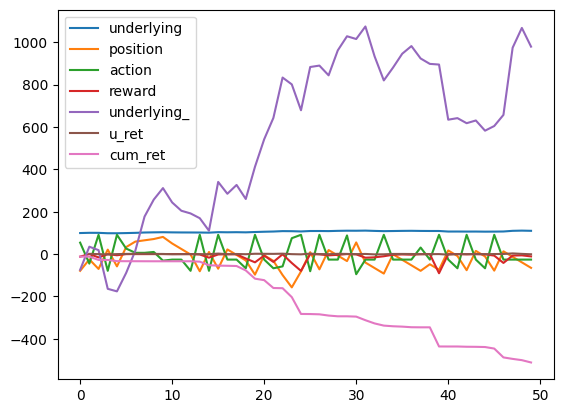

In [9]:
ss = []
ps = []
aa = []
rs = []
for state, action, reward, _, _ in history: # state, action, float(reward), next_state, float(done)
    underlying, _, pos, _ = state.tolist()
    ss.append(underlying)
    ps.append(pos)
    aa.append(action)
    rs.append(reward)

import matplotlib.pyplot as plt 
# n = 1 * 50
n = len(ss) - 50
df = pd.DataFrame({
    "underlying": ss[n:n+50],
    "position" : ps[n:n+50], 
    "action": aa[n:n+50], 
    "reward": rs[n:n+50] 
})
df["underlying_"] =  (df["underlying"] - 100) * 100
df["u_ret"] = df["underlying"].diff()
df["reward"] /= 100
df["cum_ret"] = df["reward"].cumsum() 
df["action"] -= 100
# df["underlying"].plot()
df.plot()
df